In [1]:
import numpy as np
import torch
import os
from torchvision import datasets,transforms
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [2]:
!unzip '/content/drive/MyDrive/Plant Village Classification/archive (5).zip'

Streaming output truncated to the last 5000 lines.
  inflating: plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/08c033bd-fbc3-445a-88d1-1863070e52ce___YLCV_GCREC 2872.JPG  
  inflating: plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/08dd176c-e9d9-4746-92c3-fa8dc9074347___UF.GRC_YLCV_Lab 03057.JPG  
  inflating: plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/08f78a80-46f5-45a6-937c-4d05d61c08c2___UF.GRC_YLCV_Lab 01895.JPG  
  inflating: plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/0903aa95-6e8a-4abd-a003-126fcd9a5493___YLCV_GCREC 2806.JPG  
  inflating: plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/0911d416-d73d-4c2a-8e45-207a7ceb7c9a___YLCV_GCREC 2773.JPG  
  inflating: plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/09188838-cc89-4925-94c5-d9563c4cb4bf___UF.GRC_YLCV_Lab 02974.JPG  
  inflating: plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/0922e026-b563-438d-b9ed-74

In [3]:
IMG_SIZE=224
BATCH_SIZE=32

train_transform=transforms.Compose([
    transforms.Resize((IMG_SIZE,IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],std=[0.229, 0.224, 0.225])

])

val_test_transform=transforms.Compose([
    transforms.Resize((IMG_SIZE,IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],std=[0.229, 0.224, 0.225])
])



In [4]:
from torch.utils.data import random_split

# Define the root directory for the dataset
DATA_ROOT = '/content/plantvillage/PlantVillage'

# Create the full dataset with a basic transform that only resizes and converts to tensor
# This temporary transform is applied before splitting to avoid applying augmentations prematurely
full_dataset = datasets.ImageFolder(
    root=DATA_ROOT,
    transform=transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor()
    ])
)

# Get class names from the full dataset for later use
class_names = full_dataset.classes
print(f"Classes: {class_names}")
print(f"Total length of dataset: {len(full_dataset)}")

# Define split ratios
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

# Calculate actual split sizes
total_size = len(full_dataset)
train_size = int(train_ratio * total_size)
val_size = int(val_ratio * total_size)
test_size = total_size - train_size - val_size # Ensure all images are accounted for

# Split the dataset
train_dataset, val_dataset, test_dataset = random_split(full_dataset, [train_size, val_size, test_size])#returns indices

print(f"Train dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")

Classes: ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']
Total length of dataset: 20638
Train dataset size: 14446
Validation dataset size: 3095
Test dataset size: 3097


In [5]:
print(train_dataset.indices)

[16414, 19758, 11390, 6839, 6099, 2240, 15631, 4629, 11745, 19284, 13082, 10633, 6948, 6642, 6943, 12978, 7806, 11188, 12067, 4797, 9817, 14164, 7869, 10277, 4716, 4445, 5364, 9171, 10598, 16134, 6146, 19624, 8562, 9438, 13261, 12075, 3801, 7321, 658, 15030, 9657, 6812, 17124, 4189, 7343, 9763, 28, 643, 16102, 8643, 12345, 14160, 14662, 12427, 16876, 1786, 10978, 14074, 13675, 14879, 14992, 14304, 4866, 14668, 11253, 3689, 12217, 2797, 16015, 4178, 19238, 14529, 15548, 14637, 11545, 6783, 9581, 15741, 5462, 8614, 7121, 9562, 12189, 9505, 11366, 17018, 17033, 7734, 14303, 1365, 3421, 15067, 16036, 10437, 9781, 6768, 5603, 6096, 12864, 3296, 9966, 11240, 7742, 12138, 6151, 20610, 15703, 16207, 19237, 15144, 7891, 14562, 5824, 307, 11047, 8204, 9628, 3157, 2630, 8970, 16480, 14005, 2603, 17085, 8170, 5985, 8179, 17308, 15785, 586, 5452, 5431, 12951, 14898, 19920, 9452, 18998, 14084, 1820, 7738, 5084, 2561, 7150, 8144, 7502, 9360, 4467, 7258, 8817, 18586, 8106, 15557, 10541, 9376, 2964, 80

In [6]:
train_indices = train_dataset.indices
val_indices = val_dataset.indices
test_indices = test_dataset.indices

# Get all samples from the initial full_dataset (which has paths and targets)
all_samples = full_dataset.samples

train_samples = [all_samples[i] for i in train_indices]
val_samples = [all_samples[i] for i in val_indices]
test_samples = [all_samples[i] for i in test_indices]

# Create new datasets using these samples and applying the correct transforms
class TransformedSubset(torch.utils.data.Dataset):
    def __init__(self, samples, transform=None):
        self.samples = samples
        self.transform = transform
        self.loader = datasets.folder.default_loader

    def __getitem__(self, index):
        path, target = self.samples[index]
        sample = self.loader(path)
        if self.transform is not None:
            sample = self.transform(sample)
        return sample, target

    def __len__(self):
        return len(self.samples)


train_final_dataset = TransformedSubset(train_samples, transform=train_transform)
val_final_dataset = TransformedSubset(val_samples, transform=val_test_transform)
test_final_dataset = TransformedSubset(test_samples, transform=val_test_transform)

print('Train dataset after applying transforms:', len(train_final_dataset))
print('Validation dataset after applying transforms:', len(val_final_dataset))
print('Test dataset after applying transforms:', len(test_final_dataset))

# Create DataLoaders for each dataset
train_loader = DataLoader(
    train_final_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_final_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_final_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

# Verify a batch from the training loader
train_images, train_labels = next(iter(train_loader))
print('Train images shape:', train_images.shape)
print('Train labels shape:', train_labels.shape)

# Verify a batch from the validation loader
val_images, val_labels = next(iter(val_loader))
print('Validation images shape:', val_images.shape)
print('Validation labels shape:', val_labels.shape)

Train dataset after applying transforms: 14446
Validation dataset after applying transforms: 3095
Test dataset after applying transforms: 3097
Train images shape: torch.Size([32, 3, 224, 224])
Train labels shape: torch.Size([32])
Validation images shape: torch.Size([32, 3, 224, 224])
Validation labels shape: torch.Size([32])


In [7]:
class PlantDiseaseCNN(nn.Module):
    def __init__(self,num_classes):
      super(PlantDiseaseCNN,self).__init__()
      #layers
      self.conv1=nn.Conv2d(3,32,kernel_size=3,padding=1)
      self.conv2=nn.Conv2d(32,64,kernel_size=3,padding=1)
      self.conv3=nn.Conv2d(64,128,kernel_size=3,padding=1)

      self.pool=nn.MaxPool2d(2,2)

      #classifier
      self.fc1=nn.Linear(128*28*28,256)
      self.dropout=nn.Dropout(0.5)
      self.fc2=nn.Linear(256,num_classes)

    def forward(self,x):
      x=self.pool(F.relu(self.conv1(x)))
      x=self.pool(F.relu(self.conv2(x)))
      x=self.pool(F.relu(self.conv3(x)))

      x=x.view(x.size(0),-1)#flatten
      x=F.relu(self.fc1(x))
      x=self.dropout(x)
      x=self.fc2(x)
      return x


In [8]:
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
num_classes=len(full_dataset.classes)
model=PlantDiseaseCNN(num_classes).to(device)

print(model)

PlantDiseaseCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=100352, out_features=256, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=256, out_features=15, bias=True)
)


In [9]:
#sanity check
images, labels = next(iter(train_loader))
images = images.to(device)

outputs = model(images)
print("Output shape:", outputs.shape)


Output shape: torch.Size([32, 15])


In [10]:
criterion=nn.CrossEntropyLoss()

In [11]:
import torch.optim as optim
optimizer=optim.Adam(model.parameters(),lr=0.001)


In [12]:
def calculate_accuracy(outputs, labels):
    _, predicted = torch.max(outputs, 1)
    total = labels.size(0)
    correct = (predicted == labels).sum().item()
    accuracy = correct / total
    return accuracy

In [13]:
from tqdm import tqdm
train_losses, val_losses = [], []
train_accs, val_accs = [], []

epochs=10
for epoch in range(epochs):
  model.train()
  running_loss=0.0
  running_acc=0
  for images,labels in tqdm(train_loader):
    images,labels=images.to(device),labels.to(device)
    optimizer.zero_grad()
    outputs=model(images)
    loss=criterion(outputs,labels)
    loss.backward()
    optimizer.step()
    running_loss+=loss.item()
    running_acc+=calculate_accuracy(outputs,labels)
  epoch_train_loss=running_loss/len(train_loader)
  epoch_train_acc=running_acc/len(train_loader)
  train_losses.append(epoch_train_loss)
  train_accs.append(epoch_train_acc)

  #validation
  model.eval()
  val_loss=0.0
  val_acc=0.0
  with torch.no_grad():
    for images,labels in tqdm(val_loader):
      images,labels=images.to(device),labels.to(device)
      outputs=model(images)
      loss=criterion(outputs,labels)
      val_loss+=loss.item()
      val_acc+=calculate_accuracy(outputs,labels)
    epoch_val_loss=val_loss/len(val_loader)
    epoch_val_acc=val_acc/len(val_loader)
    val_losses.append(epoch_val_loss)
    val_accs.append(epoch_val_acc)
  print(f"Epoch {epoch+1}/{epochs}")
  print(f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f}")
  print(f"Val   Loss: {epoch_val_loss:.4f} | Val   Acc: {epoch_val_acc:.4f}")


100%|██████████| 97/97 [00:08<00:00, 11.11it/s]


Epoch 1/10
Train Loss: 1.5959 | Train Acc: 0.4941
Val   Loss: 0.9463 | Val   Acc: 0.6885


100%|██████████| 97/97 [00:07<00:00, 12.48it/s]


Epoch 2/10
Train Loss: 0.9595 | Train Acc: 0.6786
Val   Loss: 0.7944 | Val   Acc: 0.7324


100%|██████████| 97/97 [00:07<00:00, 12.49it/s]


...

Epoch 8/10
Train Loss: 0.4764 | Train Acc: 0.8417
Val   Loss: 0.3837 | Val   Acc: 0.8842


100%|██████████| 97/97 [00:09<00:00,  9.92it/s]


Epoch 9/10
Train Loss: 0.4507 | Train Acc: 0.8520
Val   Loss: 0.3316 | Val   Acc: 0.8996


100%|██████████| 97/97 [00:08<00:00, 11.82it/s]

Epoch 10/10
Train Loss: 0.4225 | Train Acc: 0.8582
Val   Loss: 0.3268 | Val   Acc: 0.8992


In [14]:
#model saving
torch.save(model.state_dict(),"plant_disease_model.pth")
print('model saved')

model saved


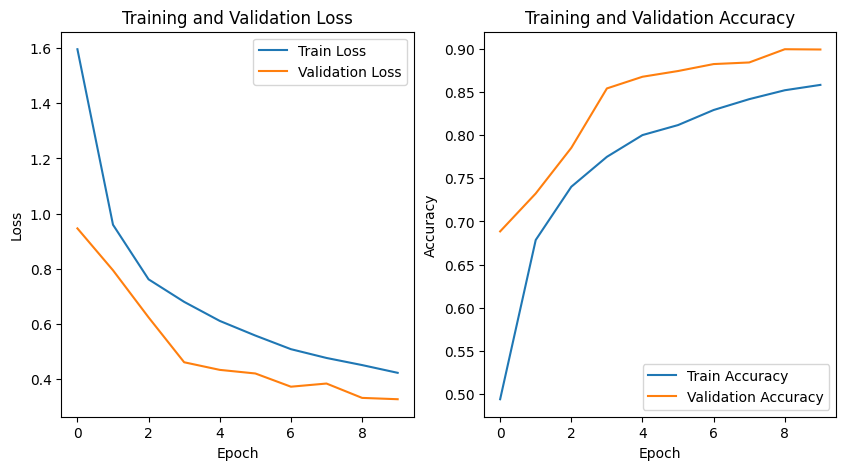

In [15]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')

plt.subplot(1,2,2)
plt.plot(train_accs, label='Train Accuracy')
plt.plot(val_accs, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.show()

In [16]:
from sklearn.metrics import confusion_matrix, classification_report

model.eval()
all_preds=[]
all_labels=[]
with torch.no_grad():
  for images,labels in test_loader:
    images,labels=images.to(device),labels.to(device)
    outputs=model(images)
    _,predicted=torch.max(outputs,1)

    all_preds.extend(predicted.cpu().numpy())
    all_labels.extend(labels.cpu().numpy())



In [17]:
print(classification_report(all_labels,all_preds,target_names=class_names))

                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.89      0.87      0.88       143
                     Pepper__bell___healthy       0.97      0.95      0.96       195
                      Potato___Early_blight       0.87      0.97      0.92       124
                       Potato___Late_blight       0.81      0.90      0.85       172
                           Potato___healthy       0.80      0.57      0.67        21
                      Tomato_Bacterial_spot       0.97      0.96      0.97       318
                        Tomato_Early_blight       0.72      0.81      0.76       145
                         Tomato_Late_blight       0.92      0.82      0.86       289
                           Tomato_Leaf_Mold       0.91      0.88      0.90       143
                  Tomato_Septoria_leaf_spot       0.86      0.90      0.88       263
Tomato_Spider_mites_Two_spotted_spider_mite       0.94      0.87

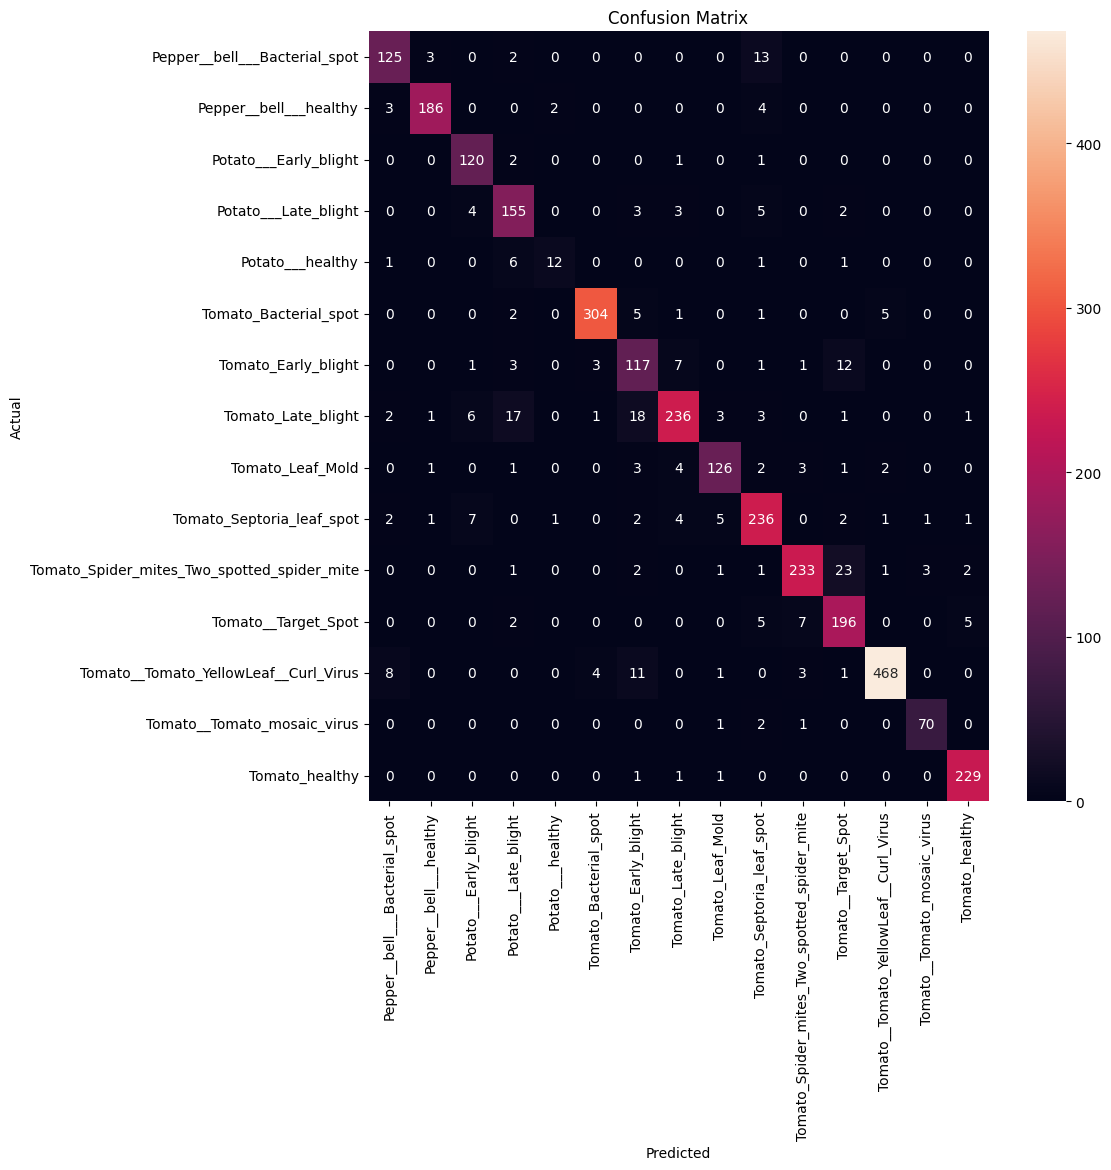

In [18]:
import seaborn as sns
cm=confusion_matrix(all_labels,all_preds)
class_names=full_dataset.classes
plt.figure(figsize=(10,10))
sns.heatmap(cm,annot=True,fmt='d',xticklabels=class_names,yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [19]:
test_acc=np.mean(np.array(all_labels)==np.array(all_preds))
print(f"test accuracy:{test_acc:.4f}")

test accuracy:0.9083


# Using Pretrained Model

In [20]:
from torchvision import models

mobilenet=models.mobilenet_v2(pretrained=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 155MB/s]


In [21]:
for param in mobilenet.parameters():
    param.requires_grad = False


In [22]:
num_classes = len(full_dataset.classes)

mobilenet.classifier = nn.Sequential(
    nn.Linear(1280, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, num_classes)
)

mobilenet = mobilenet.to(device)


In [23]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    mobilenet.classifier.parameters(),
    lr=1e-3
)


In [24]:
model=mobilenet
from tqdm import tqdm
train_losses, val_losses = [], []
train_accs, val_accs = [], []

epochs=10
for epoch in range(epochs):
  model.train()
  running_loss=0.0
  running_acc=0
  for images,labels in tqdm(train_loader):
    images,labels=images.to(device),labels.to(device)
    optimizer.zero_grad()
    outputs=model(images)
    loss=criterion(outputs,labels)
    loss.backward()
    optimizer.step()
    running_loss+=loss.item()
    running_acc+=calculate_accuracy(outputs,labels)
  epoch_train_loss=running_loss/len(train_loader)
  epoch_train_acc=running_acc/len(train_loader)
  train_losses.append(epoch_train_loss)
  train_accs.append(epoch_train_acc)

  #validation
  model.eval()
  val_loss=0.0
  val_acc=0.0
  with torch.no_grad():
    for images,labels in tqdm(val_loader):
      images,labels=images.to(device),labels.to(device)
      outputs=model(images)
      loss=criterion(outputs,labels)
      val_loss+=loss.item()
      val_acc+=calculate_accuracy(outputs,labels)
    epoch_val_loss=val_loss/len(val_loader)
    epoch_val_acc=val_acc/len(val_loader)
    val_losses.append(epoch_val_loss)
    val_accs.append(epoch_val_acc)
  print(f"Epoch {epoch+1}/{epochs}")
  print(f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f}")
  print(f"Val   Loss: {epoch_val_loss:.4f} | Val   Acc: {epoch_val_acc:.4f}")


100%|██████████| 97/97 [00:09<00:00, 10.20it/s]


Epoch 1/10
Train Loss: 0.8757 | Train Acc: 0.7304
Val   Loss: 0.3355 | Val   Acc: 0.8990


100%|██████████| 97/97 [00:09<00:00, 10.19it/s]


Epoch 2/10
Train Loss: 0.4789 | Train Acc: 0.8441
Val   Loss: 0.2508 | Val   Acc: 0.9180


100%|██████████| 97/97 [00:09<00:00, 10.21it/s]


...

Epoch 8/10
Train Loss: 0.3221 | Train Acc: 0.8911
Val   Loss: 0.2061 | Val   Acc: 0.9310


100%|██████████| 97/97 [00:09<00:00, 10.45it/s]


Epoch 9/10
Train Loss: 0.3139 | Train Acc: 0.8900
Val   Loss: 0.1700 | Val   Acc: 0.9466


100%|██████████| 97/97 [00:08<00:00, 12.11it/s]

Epoch 10/10
Train Loss: 0.3126 | Train Acc: 0.8941
Val   Loss: 0.1670 | Val   Acc: 0.9439


In [25]:
#model saving
torch.save(model.state_dict(),"mobilenet_plant_disease_model.pth")
print('model saved')

model saved


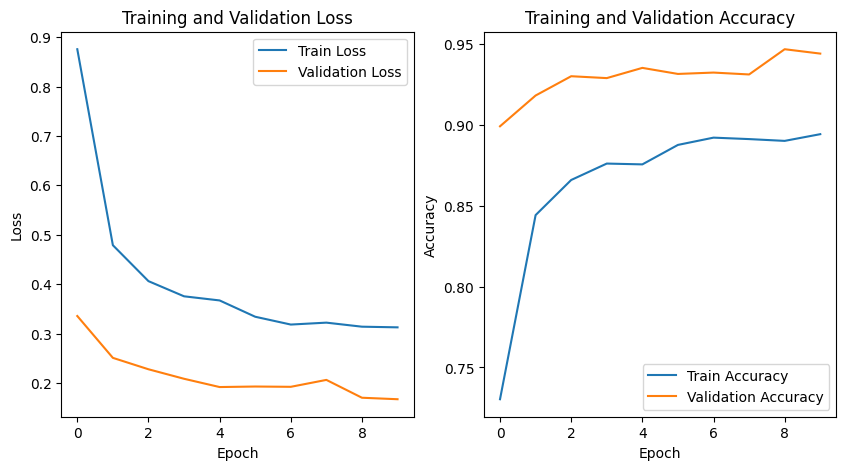

In [26]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')

plt.subplot(1,2,2)
plt.plot(train_accs, label='Train Accuracy')
plt.plot(val_accs, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.show()

In [27]:
from sklearn.metrics import confusion_matrix, classification_report

model.eval()
all_preds=[]
all_labels=[]
with torch.no_grad():
  for images,labels in test_loader:
    images,labels=images.to(device),labels.to(device)
    outputs=model(images)
    _,predicted=torch.max(outputs,1)

    all_preds.extend(predicted.cpu().numpy())
    all_labels.extend(labels.cpu().numpy())



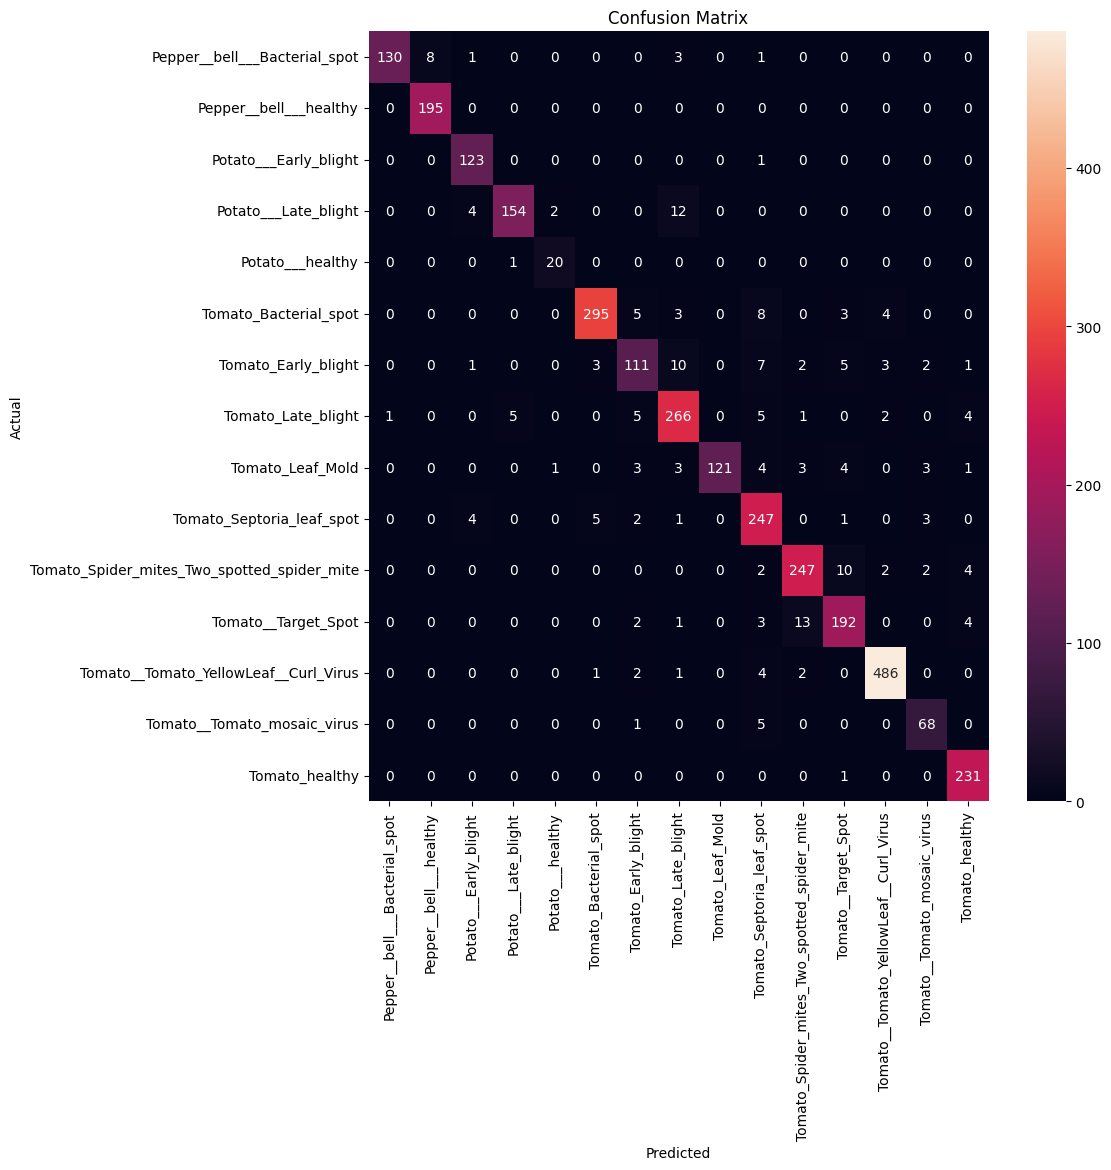

In [28]:
import seaborn as sns
cm=confusion_matrix(all_labels,all_preds)
class_names=full_dataset.classes
plt.figure(figsize=(10,10))
sns.heatmap(cm,annot=True,fmt='d',xticklabels=class_names,yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [41]:
print(classification_report(all_labels,all_preds,target_names=class_names))

                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.99      0.91      0.95       143
                     Pepper__bell___healthy       0.96      1.00      0.98       195
                      Potato___Early_blight       0.92      0.99      0.96       124
                       Potato___Late_blight       0.96      0.90      0.93       172
                           Potato___healthy       0.87      0.95      0.91        21
                      Tomato_Bacterial_spot       0.97      0.93      0.95       318
                        Tomato_Early_blight       0.85      0.77      0.80       145
                         Tomato_Late_blight       0.89      0.92      0.90       289
                           Tomato_Leaf_Mold       1.00      0.85      0.92       143
                  Tomato_Septoria_leaf_spot       0.86      0.94      0.90       263
Tomato_Spider_mites_Two_spotted_spider_mite       0.92      0.93

In [42]:
mobilenet_acc=np.mean(np.array(all_labels)==np.array(all_preds))
print(f"test accuracy:{test_acc:.4f}")

test accuracy:0.9319


# Grad Cam Visualization

In [30]:
target_layer = mobilenet.features[-1]#last convolutional layer


In [31]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        self.target_layer.register_forward_hook(self._forward_hook)

    def _forward_hook(self, module, input, output):
        self.activations = output
        output.register_hook(self._save_gradient)

    def _save_gradient(self, grad):
        self.gradients = grad

    def generate(self, x, class_idx=None):
        self.model.zero_grad()
        out = self.model(x)

        if class_idx is None:
            class_idx = out.argmax(dim=1).item()

        loss = out[:, class_idx]
        loss.backward()

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1)

        cam = torch.relu(cam)
        cam -= cam.min()
        cam /= cam.max() + 1e-8

        return cam


In [32]:
#test image
import matplotlib.pyplot as plt

images, labels = next(iter(test_loader))
images = images.to(device)

img = images[0].unsqueeze(0).to(device)
img.requires_grad = True
label = labels[0]


In [33]:
#gradcam heatmap
gradcam = GradCAM(mobilenet, target_layer)

cam = gradcam.generate(img)
cam = cam.squeeze().detach().cpu().numpy()


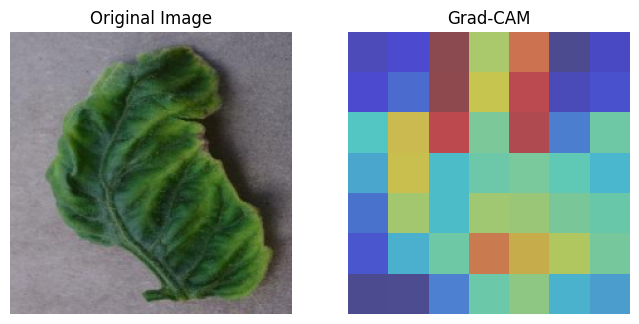

In [35]:
import numpy as np

image = img.squeeze().permute(1, 2, 0).detach().cpu().numpy()

# De-normalize for visualization
mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])
image = std * image + mean
image = np.clip(image, 0, 1)

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(image)
plt.imshow(cam, cmap="jet", alpha=0.5)
plt.title("Grad-CAM")
plt.axis("off")

plt.show()

In [37]:
import cv2


def show_gradcam(img, cam):
    cam = cv2.resize(cam, (img.shape[1], img.shape[0]))
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    overlay = heatmap * 0.4 + img * 0.6
    overlay = overlay.astype(np.uint8)

    return overlay



In [38]:
orig_img = img.squeeze().detach().cpu()
orig_img = orig_img.permute(1, 2, 0).numpy()
orig_img = (orig_img - orig_img.min()) / (orig_img.max() - orig_img.min())
orig_img = (orig_img * 255).astype(np.uint8)


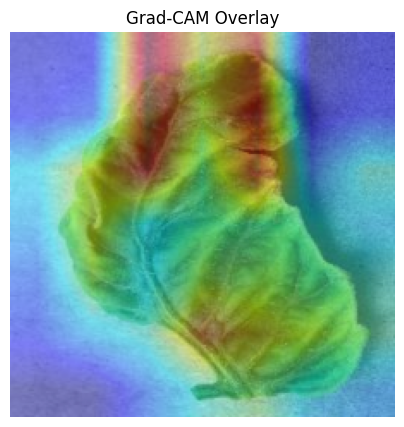

In [40]:
overlay = show_gradcam(orig_img, cam)

plt.figure(figsize=(5,5))
plt.imshow(overlay)
plt.axis("off")
plt.title("Grad-CAM Overlay")
plt.savefig("gradcam.png")
plt.show()


- Custom cnn accuracy:0.9083
-  MobileNetv2 accuracy:0.9318